# T1 FastFlux Loop Repeated — Qubit 2, Run 006

Load and plot data from `t1_fastflux_loop_repeated_qubit2_00006.h5` and associated CSVs.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import h5py

from slab_qick_calib.experiments.flux.t1_fastflux_loop import T1FastFluxLoopRepeated
from slab_qick_calib.helpers import handy
%matplotlib inline
handy.config_figs()

DATA_DIR = Path("C:/_Data/sample_50_new/data")
H5_FILE = DATA_DIR / "t1_fastflux_loop_repeated_qubit2_00011.h5"
CSV_DIR = DATA_DIR / "t1_fastflux_loop_repeated_qubit2_00011" / "csvs"

## 1. Load HDF5 and display built-in plots

In [51]:
expt = T1FastFluxLoopRepeated.from_h5file(str(H5_FILE))
#expt.display()

## 2. Inspect HDF5 contents

In [52]:
with h5py.File(H5_FILE, "r") as f:
    print("Datasets:")
    for key in f.keys():
        ds = f[key]
        print(f"  {key}: shape={ds.shape}, dtype={ds.dtype}")
    print(f"\nAttributes: {list(f.attrs.keys())[:10]}...")

data = expt.data
t1_list = data["t1_list"]
freq_pts = data["freq_pts"]
gain_pts = data["gain_pts"]
timestamps = data["timestamps"]
print(f"\nt1_list: {t1_list.shape} ({t1_list.shape[0]} sweeps x {t1_list.shape[1]} freq/gain pts)")
print(f"Time span: {timestamps[0]:.2f} — {timestamps[-1]:.2f} hours")

Datasets:
  amps: shape=(1515, 400), dtype=float64
  avgi: shape=(1515, 400), dtype=float64
  avgq: shape=(1515, 400), dtype=float64
  calib_ve: shape=(1547, 1), dtype=float64
  calib_vg: shape=(1547, 1), dtype=float64
  freq_pts: shape=(400,), dtype=float64
  gain_pts: shape=(400,), dtype=float64
  phases: shape=(1515, 400), dtype=float64
  population: shape=(1515, 400), dtype=float64
  t1_list: shape=(1515, 400), dtype=float64
  timestamps: shape=(1515,), dtype=float64
  wait_times: shape=(1515, 400), dtype=float64

Attributes: ['config']...

t1_list: (1515, 400) (1515 sweeps x 400 freq/gain pts)
Time span: 0.01 — 13.41 hours


In [53]:
# Optional: narrow the frequency range for all downstream analysis
# Set to None to use the full range
FREQ_MIN = None  # e.g. 3440
FREQ_MAX = 3410  # e.g. 3460

if FREQ_MIN is not None or FREQ_MAX is not None:
    lo = FREQ_MIN if FREQ_MIN is not None else freq_pts.min()
    hi = FREQ_MAX if FREQ_MAX is not None else freq_pts.max()
    freq_mask = (freq_pts >= lo) & (freq_pts <= hi)
    freq_pts = freq_pts[freq_mask]
    gain_pts = gain_pts[freq_mask]
    t1_list = t1_list[:, freq_mask]
    print(f"Narrowed to {lo}–{hi} MHz: {freq_mask.sum()} / {len(freq_mask)} points")
else:
    print(f"Using full frequency range: {freq_pts.min():.1f}–{freq_pts.max():.1f} MHz ({len(freq_pts)} points)")

Narrowed to 2916.7328095999997–3410 MHz: 358 / 400 points


In [54]:
# Filter out bad sweeps where calibration jumped and T1 is large across the whole line
median_per_sweep = np.nanmedian(t1_list, axis=1)
global_median = np.nanmedian(median_per_sweep)
global_iqr = np.subtract(*np.nanpercentile(median_per_sweep, [75, 25]))
threshold = global_median + 3 * global_iqr

bad_mask = median_per_sweep > threshold
n_bad = bad_mask.sum()
print(f"Median T1 per sweep: median={global_median:.2f}, IQR={global_iqr:.2f}, threshold={threshold:.2f}")
print(f"Flagged {n_bad}/{len(median_per_sweep)} sweeps as bad (median T1 > {threshold:.2f} µs)")
if n_bad > 0:
    print(f"  Bad sweep indices: {np.where(bad_mask)[0]}")
    print(f"  Their median T1 values: {median_per_sweep[bad_mask]}")
    t1_list[bad_mask] = np.nan

Median T1 per sweep: median=1.13, IQR=0.35, threshold=2.18
Flagged 21/1515 sweeps as bad (median T1 > 2.18 µs)
  Bad sweep indices: [ 110  208  244  493  544  770  786  847  916 1060 1115 1151 1240 1249
 1273 1333 1338 1350 1385 1457 1493]
  Their median T1 values: [2.29598536 3.60997293 2.82636699 4.49573001 2.82497157 4.30170932
 3.42396788 3.59377031 3.62726233 2.94015183 3.18281143 2.57374699
 3.91941587 4.02774688 3.65723259 2.63473014 2.33682186 2.92216286
 3.10059715 2.74838823 3.52943781]


## 3. T1 heatmap with robust color scale

<Figure size 800x400 with 0 Axes>

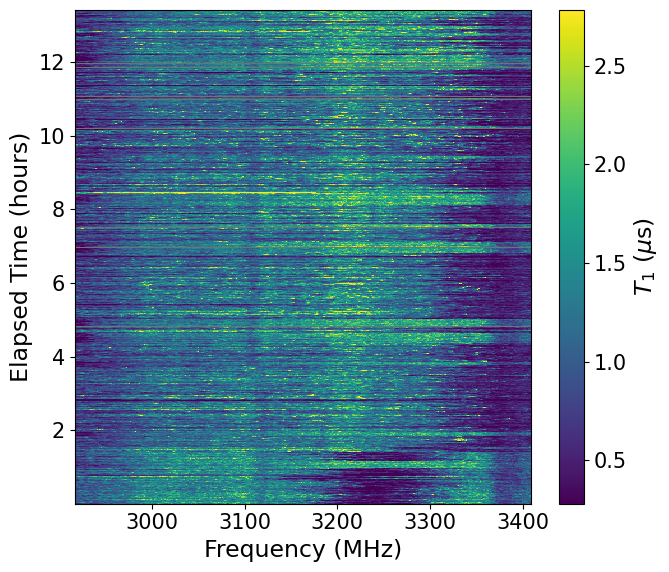

In [78]:
rc = {
        "font.size": 16,
        "axes.titlesize": 16,
        "axes.labelsize": 17,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 15,
        "figure.titlesize": 18,
        "lines.linewidth": 3,
        "lines.markersize": 8,
    }
plt.rcParams.update(rc)
# T1 heatmap with percentile-based clipping; NaN rows shown in grey
finite = t1_list[np.isfinite(t1_list)]
vmin, vmax = np.percentile(finite, [1, 99.5])

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="0.45")  # dark grey for NaN

# freq_pts goes high-to-low; flip data so column 0 = lowest freq (left edge)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(t1_list[:, ::-1], aspect="auto", origin="lower", cmap=cmap,
               vmin=vmin, vmax=vmax, interpolation="nearest",
               extent=[freq_pts[-1], freq_pts[0], timestamps[0], timestamps[-1]])
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(im, ax=ax, label="$T_1$ ($\\mu$s)")
plt.tight_layout()
plt.show()
fig.savefig("t1_heatmap.png", dpi=300)

C:\Users\circu\AppData\Local\Temp\ipykernel_14752\1915976280.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


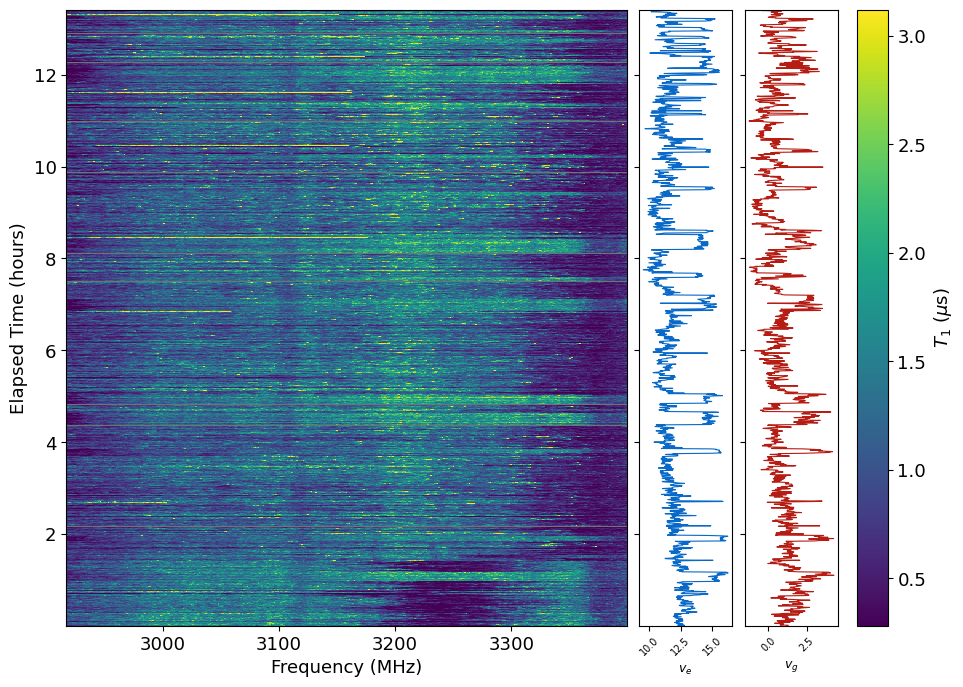

In [56]:
# Zoomed T1 heatmap with ve/vg calibration alongside — select frequency range here
freq_min = 2900  # MHz
freq_max = 3400  # MHz

mask = (freq_pts >= freq_min) & (freq_pts <= freq_max)
freq_sub = freq_pts[mask]

t1_sub = t1_list[:, mask]
finite_sub = t1_sub[np.isfinite(t1_sub)]
vmin_z, vmax_z = np.percentile(finite_sub, [1, 99.75]) if len(finite_sub) > 0 else (0, 1)

cmap_z = plt.cm.viridis.copy()
cmap_z.set_bad(color="0.45")

# Load and align calibration data
_calib_ve = data["calib_ve"].squeeze()
_calib_vg = data["calib_vg"].squeeze()
n_cal = min(len(_calib_ve), len(timestamps))
cal_ve = _calib_ve[:n_cal]
cal_vg = _calib_vg[:n_cal]
cal_times = timestamps[:n_cal]

fig, axes = plt.subplots(1, 3, figsize=(12, 8), sharey=True,
                         gridspec_kw={"width_ratios": [6, 1, 1], "wspace": 0.05})

# T1 heatmap
ax = axes[0]
im = ax.imshow(t1_sub[:, ::-1], aspect="auto", origin="lower", cmap=cmap_z,
               vmin=vmin_z, vmax=vmax_z, interpolation="nearest",
               extent=[freq_sub[-1], freq_sub[0], timestamps[0], timestamps[-1]])
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")

# ve vs time
ax = axes[1]
ax.plot(cal_ve, cal_times, "-", lw=0.8, color="C0")
ax.set_xlabel("$v_e$", fontsize=9)
ax.tick_params(axis="x", labelsize=7, rotation=45)

# vg vs time
ax = axes[2]
ax.plot(cal_vg, cal_times, "-", lw=0.8, color="C1")
ax.set_xlabel("$v_g$", fontsize=9)
ax.tick_params(axis="x", labelsize=7, rotation=45)

plt.colorbar(im, ax=axes.tolist(), label="$T_1$ ($\\mu$s)", pad=0.02)
plt.tight_layout()
plt.show()

## 4. Mean T1 vs frequency (time-averaged)

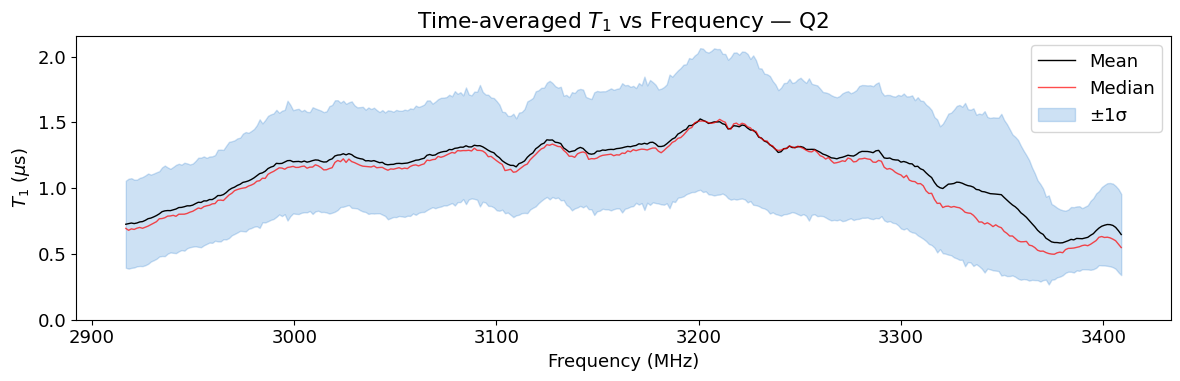

In [57]:
# Time-averaged T1 vs frequency with std band
mean_t1 = np.nanmean(t1_list, axis=0)
std_t1 = np.nanstd(t1_list, axis=0)
median_t1 = np.nanmedian(t1_list, axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freq_pts, mean_t1, "k-", lw=1, label="Mean")
ax.plot(freq_pts, median_t1, "r-", lw=1, alpha=0.7, label="Median")
ax.fill_between(freq_pts, mean_t1 - std_t1, mean_t1 + std_t1, alpha=0.2, color="C0", label="±1σ")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.set_title("Time-averaged $T_1$ vs Frequency — Q2")
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## 5. T1 time trace at selected frequencies

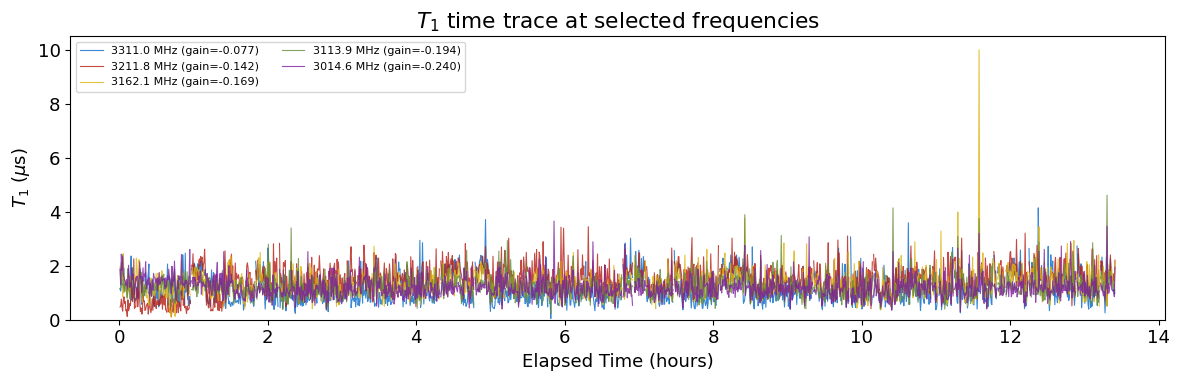

In [58]:
# Pick a few frequency indices to track T1 over time
n_freq = len(freq_pts)
idx_list = [n_freq // 5, 2 * n_freq // 5, n_freq // 2, 3 * n_freq // 5, 4 * n_freq // 5]

fig, ax = plt.subplots(figsize=(12, 4))
for idx in idx_list:
    ax.plot(timestamps, t1_list[:, idx], lw=0.8, alpha=0.8,
            label=f"{freq_pts[idx]:.1f} MHz (gain={gain_pts[idx]:.3f})")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.set_title("$T_1$ time trace at selected frequencies")
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## 6. Calibration drift (ve/vg)

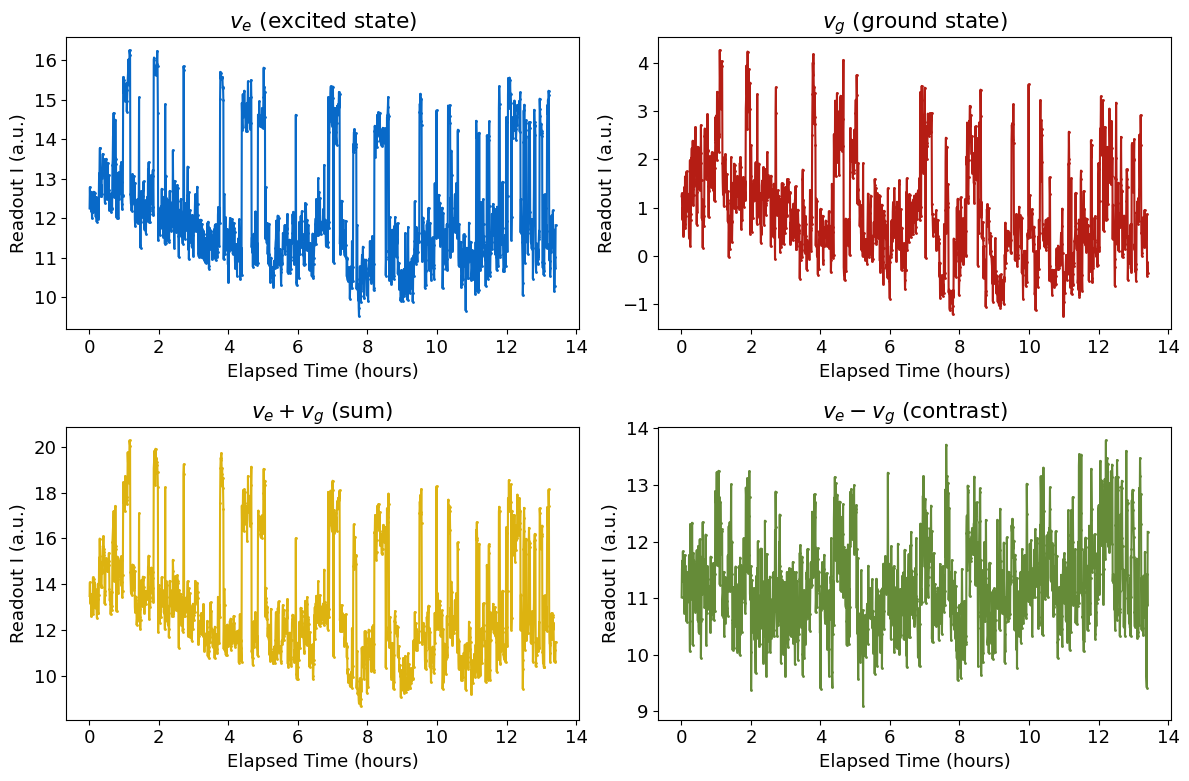

In [59]:
calib_ve = data["calib_ve"].squeeze()
calib_vg = data["calib_vg"].squeeze()

# Align lengths — there may be more calibrations than completed sweeps
n = min(len(calib_ve), len(timestamps))
calib_ve = calib_ve[:n]
calib_vg = calib_vg[:n]
calib_times = timestamps[:n]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ve vs time
ax = axes[0, 0]
ax.plot(calib_times, calib_ve, ".-", ms=2, color="C0")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("Readout I (a.u.)")
ax.set_title("$v_e$ (excited state)")

# vg vs time
ax = axes[0, 1]
ax.plot(calib_times, calib_vg, ".-", ms=2, color="C1")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("Readout I (a.u.)")
ax.set_title("$v_g$ (ground state)")

# ve + vg (sum) vs time
ax = axes[1, 0]
ax.plot(calib_times, calib_ve + calib_vg, ".-", ms=2, color="C2")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("Readout I (a.u.)")
ax.set_title("$v_e + v_g$ (sum)")

# ve - vg (contrast) vs time
ax = axes[1, 1]
ax.plot(calib_times, calib_ve - calib_vg, ".-", ms=2, color="C3")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("Readout I (a.u.)")
ax.set_title("$v_e - v_g$ (contrast)")

plt.tight_layout()
plt.show()

## 7. Load and explore CSV sweep data

In [60]:
# Load all CSVs into a single DataFrame
csv_files = sorted(CSV_DIR.glob("sweep_*.csv"))
print(f"Found {len(csv_files)} CSV files in {CSV_DIR}")

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    # Extract sweep index from filename
    df["sweep"] = int(f.stem.split("_")[1])
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], format="ISO8601")

# Apply same frequency filter as HDF5 data
if FREQ_MIN is not None or FREQ_MAX is not None:
    lo = FREQ_MIN if FREQ_MIN is not None else df_all["freq"].min()
    hi = FREQ_MAX if FREQ_MAX is not None else df_all["freq"].max()
    n_before_freq = len(df_all)
    df_all = df_all[(df_all["freq"] >= lo) & (df_all["freq"] <= hi)]
    print(f"Frequency filter {lo}–{hi} MHz: kept {len(df_all)}/{n_before_freq} rows")

# Filter out bad sweeps (same logic as HDF5 filtering)
csv_median_per_sweep = df_all.groupby("sweep")["t1"].median()
csv_global_median = csv_median_per_sweep.median()
csv_global_iqr = csv_median_per_sweep.quantile(0.75) - csv_median_per_sweep.quantile(0.25)
csv_threshold = csv_global_median + 3 * csv_global_iqr
bad_sweeps = csv_median_per_sweep[csv_median_per_sweep > csv_threshold].index
n_before = df_all["sweep"].nunique()
n_rows_before = len(df_all)

# Print details of bad sweeps
t0_csv = df_all["timestamp"].min()
for s in bad_sweeps:
    sub = df_all[df_all["sweep"] == s]
    elapsed_h = (sub["timestamp"].iloc[0] - t0_csv).total_seconds() / 3600
    print(f"  Removing sweep {s}: {len(sub)} rows, elapsed={elapsed_h:.2f}h, median T1={csv_median_per_sweep[s]:.2f} µs")

df_all = df_all[~df_all["sweep"].isin(bad_sweeps)]
n_rows_removed = n_rows_before - len(df_all)
print(f"Filtered {len(bad_sweeps)}/{n_before} bad sweeps, removed {n_rows_removed} rows (threshold: median T1 > {csv_threshold:.2f} µs)")

print(f"Total rows: {len(df_all):,}")
print(f"Columns: {list(df_all.columns)}")
df_all.head()

Found 1548 CSV files in C:\_Data\sample_50_new\data\t1_fastflux_loop_repeated_qubit2_00011\csvs
Frequency filter 2916.7328096–3410 MHz: kept 542621/606602 rows
  Removing sweep 110: 358 rows, elapsed=0.96h, median T1=2.30 µs
  Removing sweep 210: 358 rows, elapsed=1.82h, median T1=3.61 µs
  Removing sweep 247: 358 rows, elapsed=2.14h, median T1=2.83 µs
  Removing sweep 499: 358 rows, elapsed=4.31h, median T1=4.50 µs
  Removing sweep 551: 358 rows, elapsed=4.77h, median T1=2.82 µs
  Removing sweep 779: 358 rows, elapsed=6.77h, median T1=4.30 µs
  Removing sweep 797: 358 rows, elapsed=6.92h, median T1=3.42 µs
  Removing sweep 859: 358 rows, elapsed=7.46h, median T1=3.59 µs
  Removing sweep 929: 358 rows, elapsed=8.07h, median T1=3.63 µs
  Removing sweep 1075: 358 rows, elapsed=9.34h, median T1=2.94 µs
  Removing sweep 1131: 358 rows, elapsed=9.83h, median T1=3.18 µs
  Removing sweep 1168: 358 rows, elapsed=10.14h, median T1=2.57 µs
  Removing sweep 1259: 358 rows, elapsed=10.93h, median 

,timestamp,gain,freq,wait_time,population,t1,elapsed_s,sweep
42,2026-03-17 12:48:27.903550,0.012884,3408.904968,0.358944,0.657809,0.856994,3.308175,0
43,2026-03-17 12:48:27.972015,0.011220,3407.526334,0.428497,0.695046,1.177909,3.376640,0
44,2026-03-17 12:48:28.058638,0.009576,3406.147701,0.588955,0.455142,0.748216,3.463263,0
45,2026-03-17 12:48:28.118163,0.007950,3404.769067,0.374108,0.640816,0.840668,3.522788,0
46,2026-03-17 12:48:28.200934,0.006342,3403.390434,0.420334,0.607633,0.843731,3.605559,0


## 8. CSV-based plots: T1 distribution and wait_time adaptation

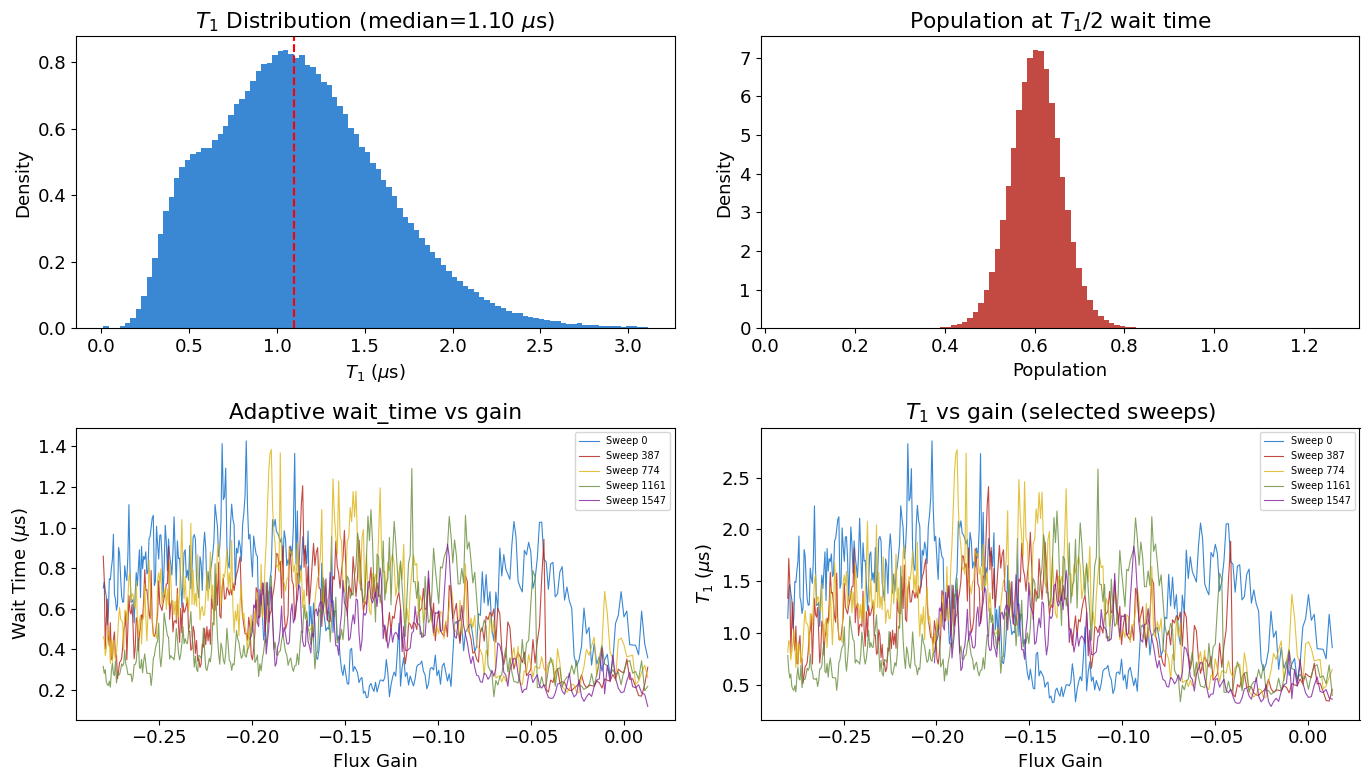

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# T1 histogram
ax = axes[0, 0]
valid_t1 = df_all["t1"].dropna()
valid_t1 = valid_t1[(valid_t1 > 0) & (valid_t1 < valid_t1.quantile(0.9975))]
ax.hist(valid_t1, bins=100, edgecolor="none", alpha=0.8, density=True)
ax.set_xlabel("$T_1$ ($\\mu$s)")
ax.set_ylabel("Density")
ax.set_title(f"$T_1$ Distribution (median={valid_t1.median():.2f} $\\mu$s)")
ax.axvline(valid_t1.median(), color="r", ls="--", lw=1.5)

# Population histogram
ax = axes[0, 1]
valid_pop = df_all["population"].dropna()
ax.hist(valid_pop, bins=100, edgecolor="none", alpha=0.8, color="C1", density=True)
ax.set_xlabel("Population")
ax.set_ylabel("Density")
ax.set_title("Population at $T_1$/2 wait time")

# Wait time vs gain (colored by sweep)
ax = axes[1, 0]
for sweep_idx in [0, len(csv_files) // 4, len(csv_files) // 2, 3 * len(csv_files) // 4, len(csv_files) - 1]:
    sub = df_all[df_all["sweep"] == sweep_idx]
    if len(sub) > 0:
        ax.plot(sub["gain"], sub["wait_time"], lw=0.8, alpha=0.8, label=f"Sweep {sweep_idx}")
ax.set_xlabel("Flux Gain")
ax.set_ylabel("Wait Time ($\\mu$s)")
ax.set_title("Adaptive wait_time vs gain")
ax.legend(fontsize=7)

# T1 vs gain for a few sweeps
ax = axes[1, 1]
for sweep_idx in [0, len(csv_files) // 4, len(csv_files) // 2, 3 * len(csv_files) // 4, len(csv_files) - 1]:
    sub = df_all[df_all["sweep"] == sweep_idx]
    if len(sub) > 0:
        ax.plot(sub["gain"], sub["t1"], lw=0.8, alpha=0.8, label=f"Sweep {sweep_idx}")
ax.set_xlabel("Flux Gain")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.set_title("$T_1$ vs gain (selected sweeps)")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

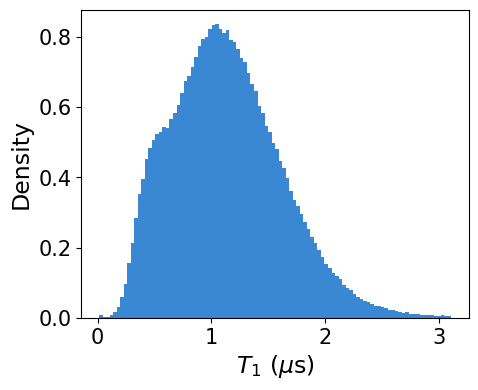

In [77]:
fig, ax = plt.subplots(figsize=(5, 4))
# T1 histogram
valid_t1 = df_all["t1"].dropna()
valid_t1 = valid_t1[(valid_t1 > 0) & (valid_t1 < valid_t1.quantile(0.9975))]
ax.hist(valid_t1, bins=100, edgecolor="none", alpha=0.8, density=True)
ax.set_xlabel("$T_1$ ($\\mu$s)")
ax.set_ylabel("Density")
plt.show()
plt.savefig("t1_histogram.png", dpi=300)

## 9. T1 vs gain heatmap from CSVs (with absolute timestamps)

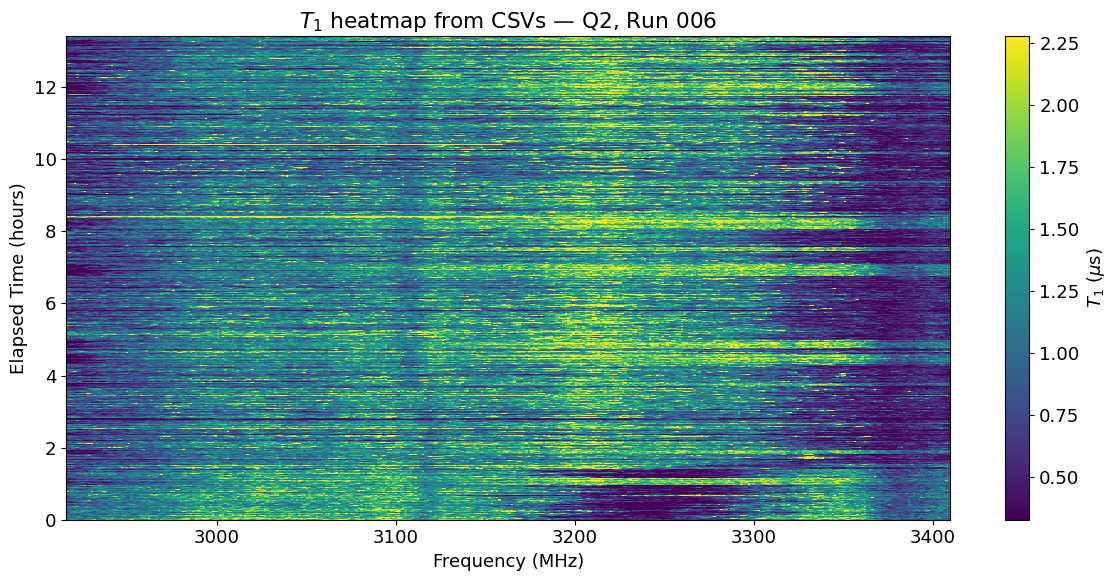

In [62]:
# Pivot CSV data into a 2D grid: sweep x freq -> T1
pivot = df_all.pivot_table(index="sweep", columns="freq", values="t1", aggfunc="first")
sweep_ids = pivot.index.values
freq_vals = pivot.columns.values
t1_grid = pivot.values

# Use absolute timestamps for y-axis (hours since first measurement)
t0 = df_all["timestamp"].min()
sweep_hours = df_all.groupby("sweep")["timestamp"].first().sort_index()
sweep_hours = (sweep_hours - t0).dt.total_seconds().values / 3600

finite = t1_grid[np.isfinite(t1_grid)]
vmin, vmax = np.percentile(finite, [2, 98])

fig, ax = plt.subplots(figsize=(12, 6))
mesh = ax.pcolormesh(freq_vals, sweep_hours[:len(t1_grid)], t1_grid,
                     cmap="viridis", shading="auto", vmin=vmin, vmax=vmax, rasterized=True)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
ax.set_title("$T_1$ heatmap from CSVs — Q2, Run 006")
plt.colorbar(mesh, ax=ax, label="$T_1$ ($\\mu$s)")
plt.tight_layout()
plt.show()

## 10. avgi vs frequency vs time heatmap

Loaded avgi from H5: (1515, 358)


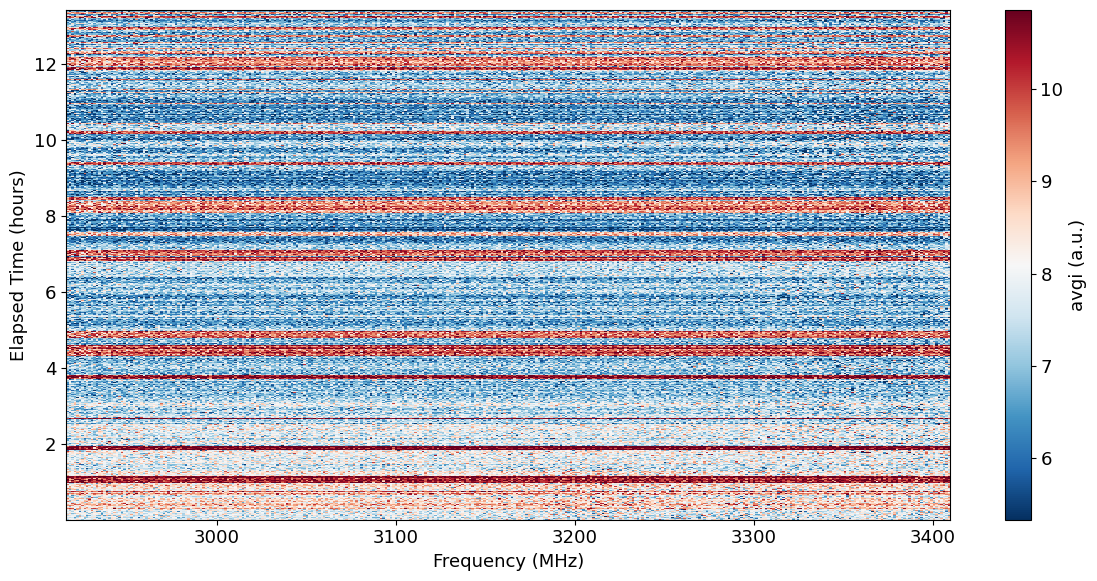

In [63]:
# Load avgi from H5 if available, otherwise reconstruct from CSVs + calibration
if "avgi" in data and data["avgi"].size > 0:
    avgi_grid = data["avgi"]
    # Apply same frequency mask if narrowed
    _all_freq = data["freq_pts"]
    if len(freq_pts) < len(_all_freq):
        lo = freq_pts.min()
        hi = freq_pts.max()
        _mask = (_all_freq >= lo) & (_all_freq <= hi)
        avgi_grid = avgi_grid[:, _mask]
    avgi_hours = timestamps[:len(avgi_grid)]
    avgi_freqs = freq_pts
    print(f"Loaded avgi from H5: {avgi_grid.shape}")
else:
    print("avgi not in H5 (old data) — reconstructing from CSVs + calibration")
    calib_ve_all = data["calib_ve"]
    calib_vg_all = data["calib_vg"]
    n_calib = calib_ve_all.shape[0]

    pivot_pop = df_all.pivot_table(index="sweep", columns="freq", values="population", aggfunc="first")
    pop_grid = pivot_pop.values
    n_csv_sweeps = pop_grid.shape[0]

    avgi_grid = np.full_like(pop_grid, np.nan)
    for s in range(n_csv_sweeps):
        ci = min(s // 10, n_calib - 1)
        avgi_grid[s] = pop_grid[s] * (calib_ve_all[ci] - calib_vg_all[ci]) + calib_vg_all[ci]

    t0 = df_all["timestamp"].min()
    avgi_hours = df_all.groupby("sweep")["timestamp"].first().sort_index()
    avgi_hours = (avgi_hours - t0).dt.total_seconds().values / 3600
    avgi_freqs = pivot_pop.columns.values

finite_avgi = avgi_grid[np.isfinite(avgi_grid)]
vmin_a, vmax_a = np.percentile(finite_avgi, [2, 98])

fig, ax = plt.subplots(figsize=(12, 6))
mesh = ax.pcolormesh(avgi_freqs, avgi_hours[:len(avgi_grid)], avgi_grid, cmap="RdBu_r",
                     shading="auto", vmin=vmin_a, vmax=vmax_a, rasterized=True)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(mesh, ax=ax, label="avgi (a.u.)")
plt.tight_layout()
plt.show()

In [64]:
-np.log(9/11)

np.float64(0.2006706954621511)

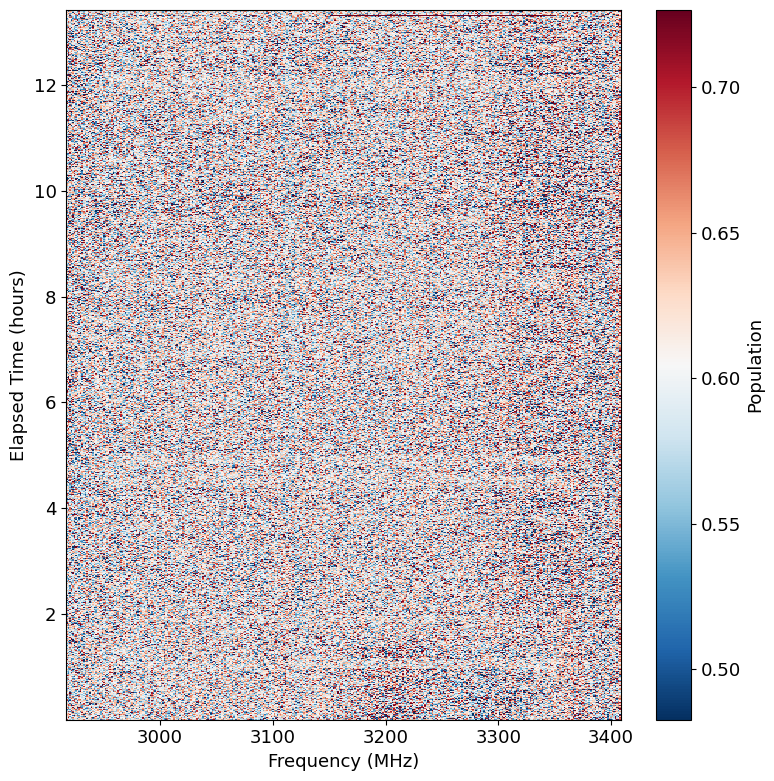

In [65]:
# Population heatmap (from H5)
pop_grid = data["population"]
_all_freq = data["freq_pts"]
if len(freq_pts) < len(_all_freq):
    _mask = (_all_freq >= freq_pts.min()) & (_all_freq <= freq_pts.max())
    pop_grid = pop_grid[:, _mask]

cmap_pop = plt.cm.RdBu_r.copy()
cmap_pop.set_bad(color="0.45")

finite_pop = pop_grid[np.isfinite(pop_grid)]
vmin_p, vmax_p = np.percentile(finite_pop, [2, 98])

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(pop_grid[:, ::-1], aspect="auto", origin="lower", cmap=cmap_pop,
               vmin=vmin_p, vmax=vmax_p, interpolation="nearest",
               extent=[freq_pts[-1], freq_pts[0], timestamps[0], timestamps[-1]])
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(im, ax=ax, label="Population")
plt.tight_layout()
plt.show()

C:\Users\circu\AppData\Local\Temp\ipykernel_14752\3987343282.py:2: RuntimeWarning: Mean of empty slice
  mean_t1_vs_time = np.nanmean(t1_list, axis=1)
C:\Users\circu\AppData\Local\Temp\ipykernel_14752\3987343282.py:3: RuntimeWarning: All-NaN slice encountered
  median_t1_vs_time = np.nanmedian(t1_list, axis=1)
c:\Users\circu\anaconda3\envs\qick_calib\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


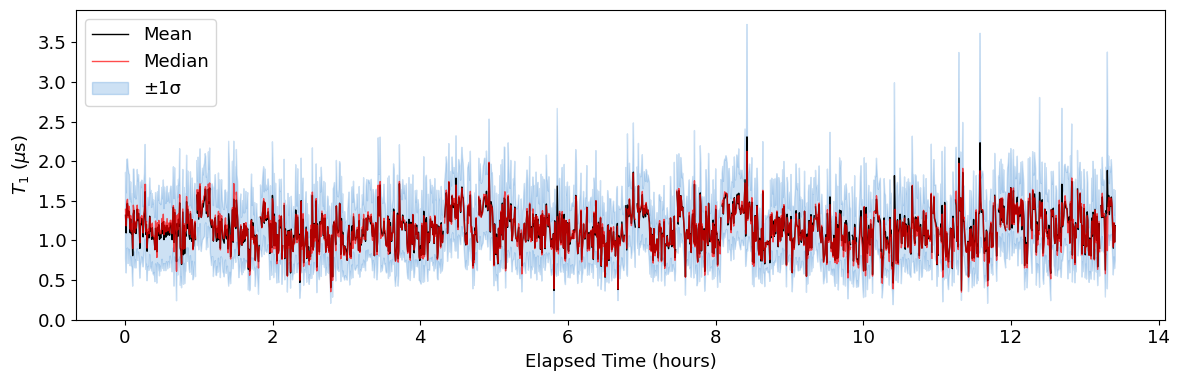

In [66]:
# Average T1 across all frequencies as a function of time
mean_t1_vs_time = np.nanmean(t1_list, axis=1)
median_t1_vs_time = np.nanmedian(t1_list, axis=1)
std_t1_vs_time = np.nanstd(t1_list, axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(timestamps, mean_t1_vs_time, "k-", lw=1, label="Mean")
ax.plot(timestamps, median_t1_vs_time, "r-", lw=1, alpha=0.7, label="Median")
ax.fill_between(timestamps, mean_t1_vs_time - std_t1_vs_time,
                mean_t1_vs_time + std_t1_vs_time, alpha=0.2, color="C0", label="±1σ")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()